# Классификация текста: анализ тональности отзывов о фильмах

**Задача:** бинарная классификация отзывов на `positive` / `negative`.

**План работы:**
1. Анализ данных
2. Предобработка текста и векторизация (TF-IDF)
3. Baseline-модель: Logistic Regression
4. Улучшенная модель: LinearSVC + подбор гиперпараметров (GridSearchCV)
5. Проверка на переобучение
6. Визуализация (confusion matrix)
7. Итоговые метрики и сохранение модели

Для начала импортируем все библиотеки, которые будем использовать в работе.

In [1]:
import time
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import joblib

np.random.seed(42)


## 1. Анализ данных

Загрузим данные в переменную df и проанализируем данные.

In [2]:
df = pd.read_csv('../data/texts/review.csv')

print(f"Размер датасета: {df.shape}")

print("\nБаланс классов:")
print(df['sentiment'].value_counts())

print("\nПропуски:")
print(df.isna().sum())

print("\nСтатистика длины отзывов:")
print(df['review'].str.len().describe())

df.head()


Размер датасета: (60000, 2)

Баланс классов:
sentiment
negative    30000
positive    30000
Name: count, dtype: int64

Пропуски:
review       0
sentiment    0
dtype: int64

Статистика длины отзывов:
count    60000.000000
mean      1286.910800
std        974.341356
min         41.000000
25%        687.000000
50%        955.000000
75%       1562.250000
max      13704.000000
Name: review, dtype: float64


,review,sentiment
0,Even for a tired movie model as the nature vs....,negative
1,As others have pointed out this movie is a loa...,negative
2,"Excellent view of a mature woman, that is goin...",positive
3,I am so glad that i got a chance to see this r...,positive
4,There's more to offer in the opening of The Od...,positive


Видим, что датасет сбалансирован (30000 negative / 30000 positive), пропусков нет. Отзывы содержат HTML-разметку, перед векторизацией надо будет очистить датасет. Длина отзывов очень сильно варьируется, от 41 до 13704 символов. Медианное значение 955 символов.

## 2. Предобработка текста и векторизация (TF-IDF)

Необходимо обработать текст. Для этого напишем функцию clean_text, которая очистит каждый отзыв от тегов, приведет все к нижнему регистру, а также оставит только слова. Разобьем датасет на трейн и тест с stratify 'sentiment'.

**Параметры `TfidfVectorizer`:**
- `max_features=20000` - ограничение словаря топ-20000 признаков;
- `ngram_range=(1, 2)` - учитываем не только отдельные слова, но и биграммы;
- `min_df=5` — отсекаем редкие слова/биграммы, встречающиеся менее чем в 5 документах (шум, опечатки);
- `stop_words='english'` — убираем стоп-слова (the, at и др).

Векторизатор обучается **только на train** (`fit_transform`), на test применяется уже обученный (`transform`) — чтобы избежать утечки данных.

In [9]:
def clean_text(text):
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text

df['review_clean'] = df['review'].apply(clean_text)

X_train, X_test, y_train, y_test = train_test_split(
    df['review_clean'], df['sentiment'],
    test_size=0.2, random_state=42, stratify=df['sentiment']
)

vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=5,
    stop_words='english'
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"Train: {X_train_vec.shape}, Test: {X_test_vec.shape}")

Train: (48000, 20000), Test: (12000, 20000)


## 3. Baseline-модель: Logistic Regression

Используем логрегу как бейслайн. Она хорошо интерпритируется в рамках поставленной задачи и быстро вычисляет на CPU нашу задачу.

In [10]:
start = time.time()

log_reg = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
log_reg.fit(X_train_vec, y_train)

train_time_lr = time.time() - start
print(f"Время обучения: {train_time_lr:.1f} сек")

Время обучения: 1.4 сек


In [12]:
y_pred_lr = log_reg.predict(X_test_vec)

f1_lr = f1_score(y_test, y_pred_lr, pos_label='positive')
precision_lr = precision_score(y_test, y_pred_lr, pos_label='positive')
recall_lr = recall_score(y_test, y_pred_lr, pos_label='positive')

print("Logistic Regression (baseline)")
print(f"F1-score:  {f1_lr:.4f} (порог > 0.75)")
print(f"Precision: {precision_lr:.4f} (порог > 0.70)")
print(f"Recall:    {recall_lr:.4f} (порог > 0.70)")
print()
print(classification_report(y_test, y_pred_lr))


Logistic Regression (baseline)
F1-score:  0.9219 (порог > 0.75)
Precision: 0.9193 (порог > 0.70)
Recall:    0.9245 (порог > 0.70)

              precision    recall  f1-score   support

    negative       0.92      0.92      0.92      6000
    positive       0.92      0.92      0.92      6000

    accuracy                           0.92     12000
   macro avg       0.92      0.92      0.92     12000
weighted avg       0.92      0.92      0.92     12000



**Вывод:** baseline-модель уже уверенно проходит все три порога (F1=0.92, Precision=0.92, Recall=0.92 против требуемых 0.75/0.70/0.70). Попробуем улучшить результат более мощной линейной моделью — LinearSVC.

## 4. Улучшенная модель: LinearSVC + подбор гиперпараметров

Подбираем ключевой параметр регуляризации `C` через `GridSearchCV`.

In [13]:
param_grid = {'C': [0.01, 0.1, 0.5, 1.0, 2.0, 3.0]}

grid_search = GridSearchCV(
    LinearSVC(random_state=42, max_iter=2000),
    param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1
)

start = time.time()
grid_search.fit(X_train_vec, y_train)
grid_search_time = time.time() - start

print(f"Время подбора гиперпараметров: {grid_search_time:.1f} сек")
print(f"Лучший C: {grid_search.best_params_['C']}")
print(f"Лучший F1: {grid_search.best_score_:.4f}")

svm_model = grid_search.best_estimator_


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Время подбора гиперпараметров: 48.3 сек
Лучший C: 2.0
Лучший F1: 0.9390


In [14]:
y_pred_svm = svm_model.predict(X_test_vec)

f1_svm = f1_score(y_test, y_pred_svm, pos_label='positive')
precision_svm = precision_score(y_test, y_pred_svm, pos_label='positive')
recall_svm = recall_score(y_test, y_pred_svm, pos_label='positive')

print("LinearSVC (после подбора C через GridSearchCV)")
print(f"F1-score:  {f1_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall:    {recall_svm:.4f}")
print()
print(classification_report(y_test, y_pred_svm))


LinearSVC (после подбора C через GridSearchCV)
F1-score:  0.9503
Precision: 0.9528
Recall:    0.9478

              precision    recall  f1-score   support

    negative       0.95      0.95      0.95      6000
    positive       0.95      0.95      0.95      6000

    accuracy                           0.95     12000
   macro avg       0.95      0.95      0.95     12000
weighted avg       0.95      0.95      0.95     12000



Качество модели сильно улучшилось, получили хороший результат.

## 5. Проверка на переобучение

Сравниваем F1 на train и на test, проверим не переобучилась ли наша модель.

In [15]:
y_pred_train_svm = svm_model.predict(X_train_vec)
f1_train_svm = f1_score(y_train, y_pred_train_svm, pos_label='positive')

print(f"F1 train: {f1_train_svm:.4f}")
print(f"F1 test:  {f1_svm:.4f}")
print(f"Разница:  {f1_train_svm - f1_svm:.4f}")


F1 train: 0.9963
F1 test:  0.9503
Разница:  0.0460


Разница не такая критичная для этой задачи, можем использовать полученную модель дальше

## 6. Визуализация: матрица ошибок (confusion matrix)

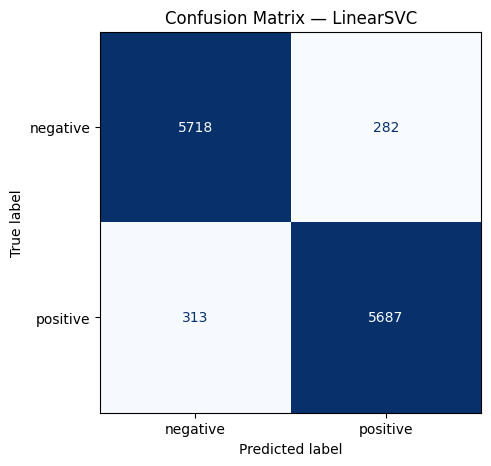

In [16]:
cm = confusion_matrix(y_test, y_pred_svm, labels=['negative', 'positive'])

fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['negative', 'positive'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — LinearSVC')
plt.tight_layout()
plt.show()


**Вывод по матрице ошибок:** модель ошибается симметрично на обоих классах, без перекоса в одну сторону. Это ожидаемо для сбалансированного датасета и говорит об устойчивом качестве классификации по обоим классам.

## 7. Итоговые метрики и сохранение модели

In [17]:
results = pd.DataFrame({
    'Модель': ['Logistic Regression (baseline)', 'LinearSVC (tuned)'],
    'F1-score': [f1_lr, f1_svm],
    'Precision': [precision_lr, precision_svm],
    'Recall': [recall_lr, recall_svm]
})

print("Пороги: F1 > 0.75, Precision > 0.70, Recall > 0.70\n")
results

Пороги: F1 > 0.75, Precision > 0.70, Recall > 0.70



,Модель,F1-score,Precision,Recall
0,Logistic Regression (baseline),0.921888,0.919291,0.924500
1,LinearSVC (tuned),0.950288,0.952756,0.947833


**Итог:** финальная модель — `LinearSVC` с параметром `C`, подобранным через `GridSearchCV`. Она превосходит baseline (логрегу) по всем трём метрикам и с большим запасом проходит требуемые пороги.

In [ ]:
import os

os.makedirs('../model', exist_ok=True)

joblib.dump(svm_model, '../models/model.pkl')
joblib.dump(vectorizer, '../models/vectorizer.pkl')

print("Модель и векторизатор сохранены в /models")

Модель и векторизатор сохранены в /model
